Nikita Gautam
2432231
Worsheet-6

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week6/FruitinAmazon.zip"

In [ ]:
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [ ]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['test', 'train']


In [ ]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir = "/content/dataset/FruitinAmazon/test"

In [ ]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError, OSError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

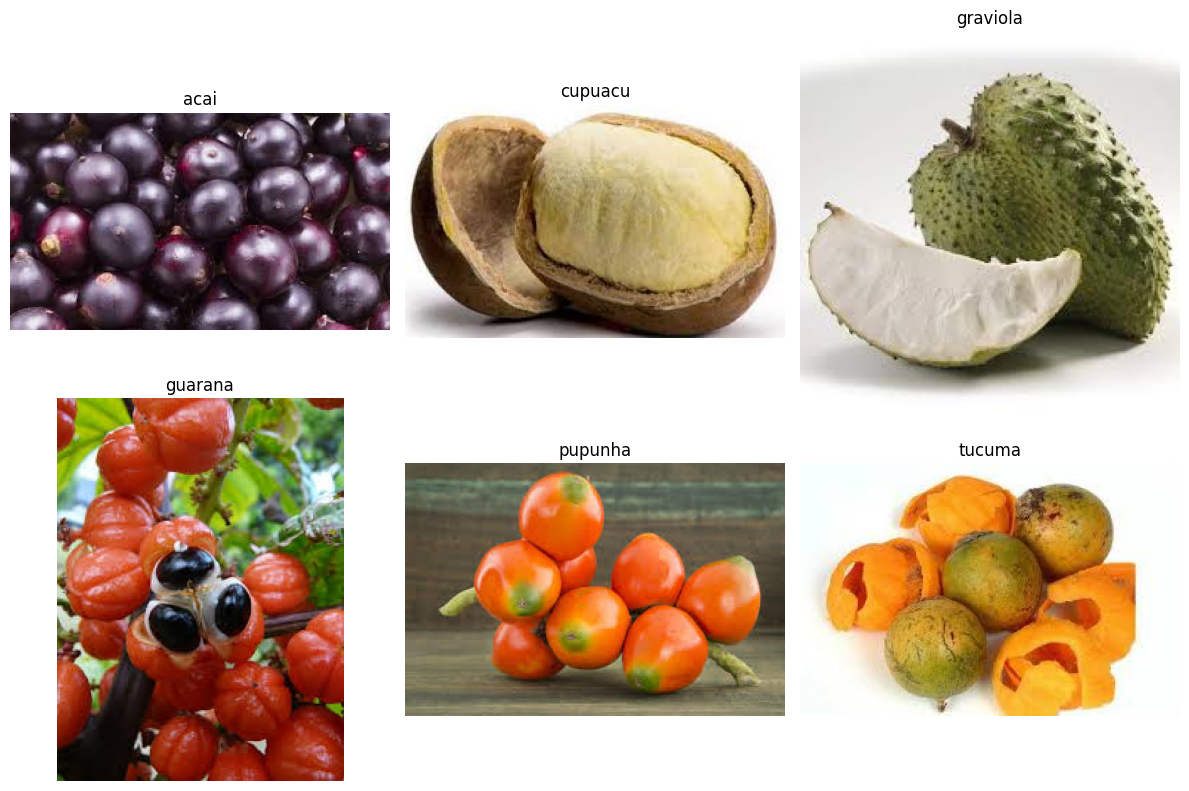

In [ ]:
num_classes = len(selected_images)
cols = 3
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


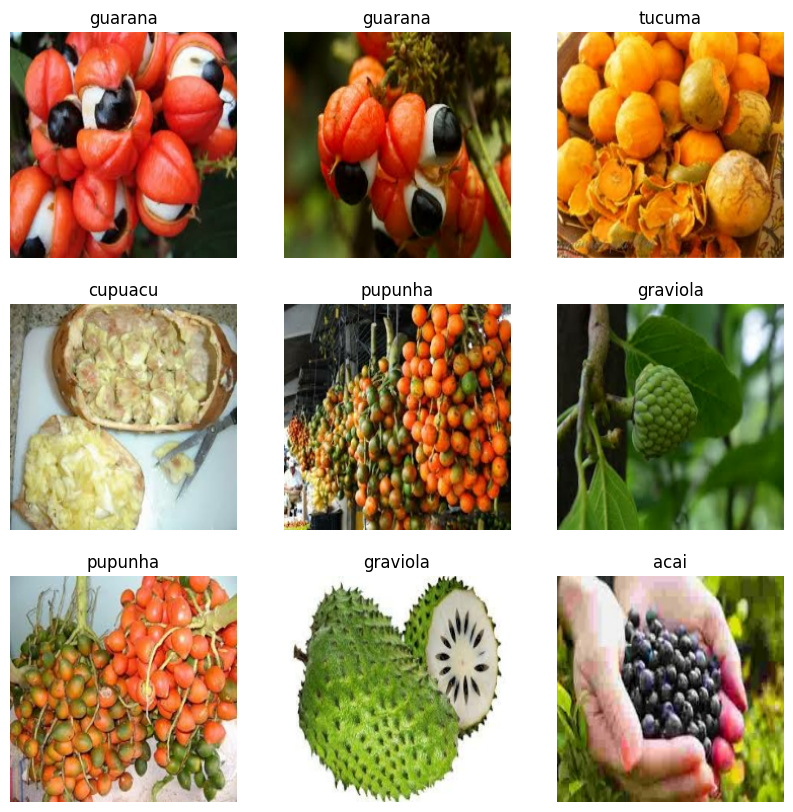

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

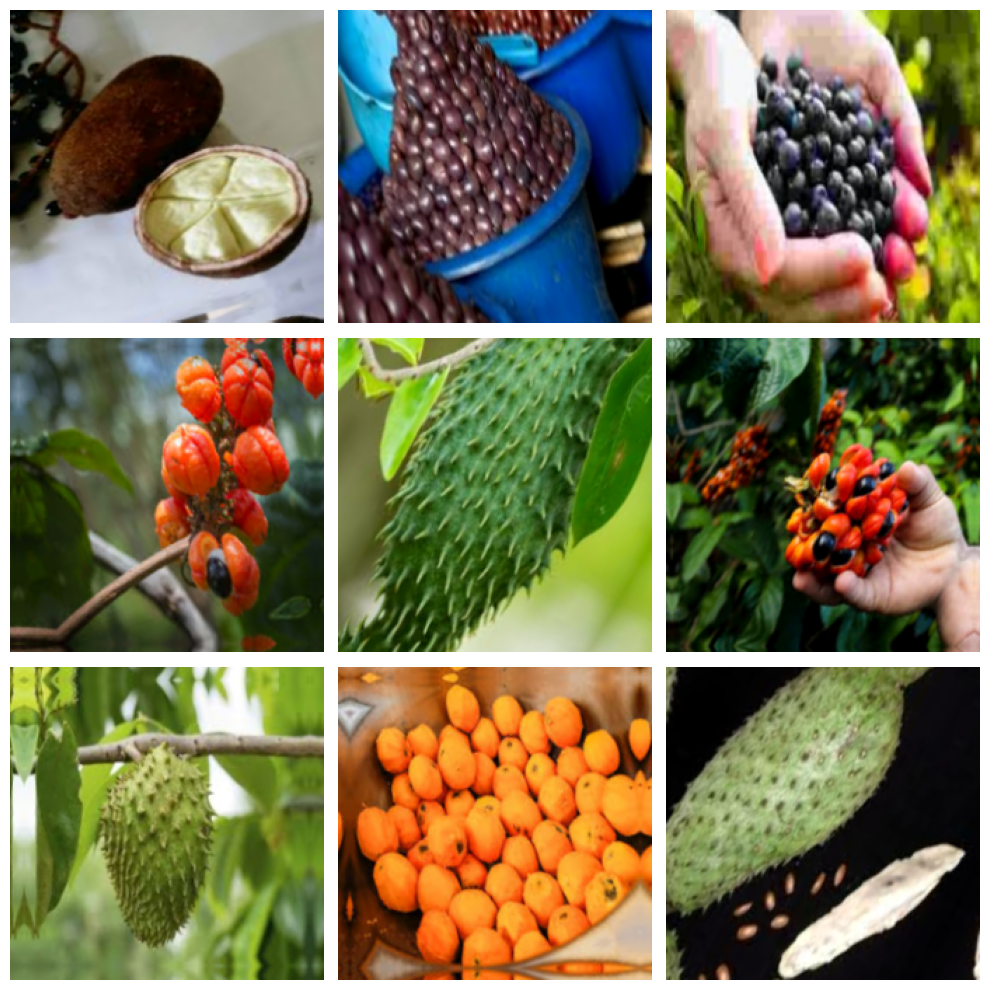

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Rescaling
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fully connected layers
    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.1528 - loss: 2.5593 - val_accuracy: 0.1111 - val_loss: 1.8697
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.1389 - loss: 2.3490 - val_accuracy: 0.1111 - val_loss: 1.8496
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.1528 - loss: 2.2941 - val_accuracy: 0.0556 - val_loss: 1.8296
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.1528 - loss: 2.1677 - val_accuracy: 0.1111 - val_loss: 1.8435
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.1667 - loss: 2.1386 - val_accuracy: 0.0556 - val_loss: 1.8543
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.1806 - loss: 2.2016 - val_accuracy: 0.1667 - val_loss: 1.8733
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.1806 - loss: 2.1438 - val_accuracy: 0.2222 - val_loss: 1.9047
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.2361 - loss: 2.0295 - val_accuracy: 0.2222 - val_loss: 1.9182


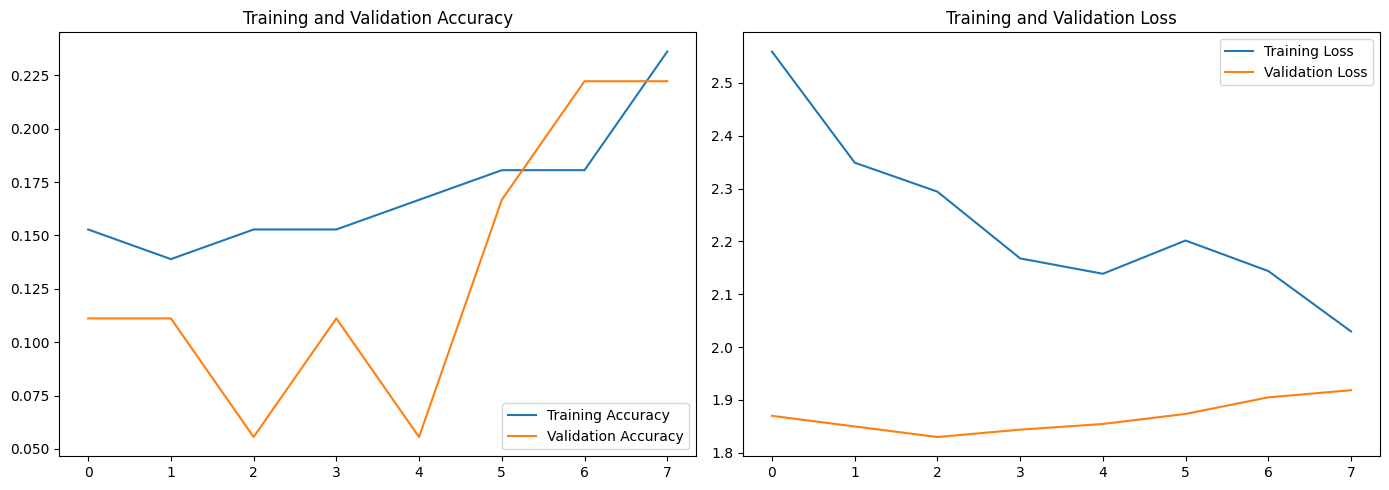

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1333 - loss: 1.8084
Test Loss: 1.8084
Test Accuracy: 0.1333


In [ ]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted labels: [1 1 1 1 1 1 5 0 1 0]
Actual labels:    [0 0 0 0 0 1 1 1 1 1]


In [ ]:
print("Classification Report for CNN Model:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report for CNN Model:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.10      0.40      0.16         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.13        30
   macro avg       0.08      0.13      0.09        30
weighted avg       0.08      0.13      0.09        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


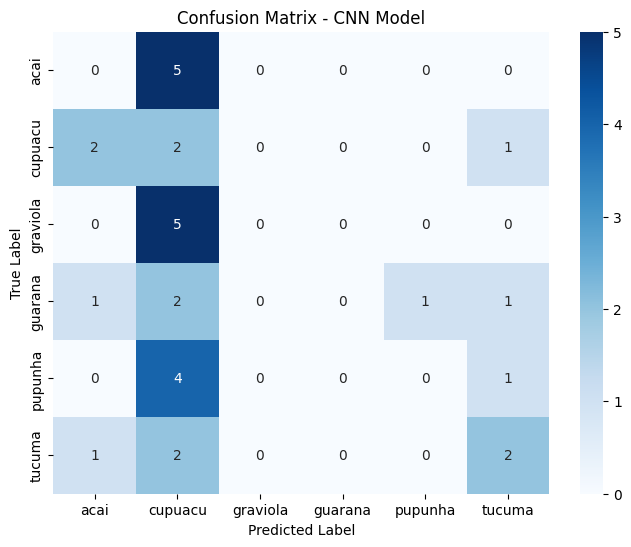

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN Model")
plt.show()

In [ ]:
model.save("cnn_fruits_model.keras")
print("CNN model saved successfully.")

CNN model saved successfully.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
train_ds_tl = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size
)

val_ds_tl = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size
)

test_ds_tl = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [ ]:
def preprocess_for_vgg(x, y):
    x = preprocess_input(tf.cast(x, tf.float32))
    return x, y

train_ds_tl = train_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)
test_ds_tl = test_ds_tl.map(preprocess_for_vgg).prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,422 (57.15 MB)

 Trainable params: 265,734 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
callbacks_tl = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_vgg16_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

history_tl = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=callbacks_tl
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 25s/step - accuracy: 0.1667 - loss: 9.6163 - val_accuracy: 0.2222 - val_loss: 4.9399
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 67s 20s/step - accuracy: 0.4306 - loss: 4.0666 - val_accuracy: 0.5556 - val_loss: 2.3359
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 23s/step - accuracy: 0.6528 - loss: 2.2055 - val_accuracy: 0.5556 - val_loss: 2.6864
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 21s/step - accuracy: 0.7361 - loss: 1.6245 - val_accuracy: 0.6667 - val_loss: 2.0554
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 21s/step - accuracy: 0.8472 - loss: 0.6350 - val_accuracy: 0.7222 - val_loss: 1.9103
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 21s/step - accuracy: 0.8889 - loss: 0.4128 - val_accuracy: 0.7222 - val_loss: 2.0871
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 25s/step - accuracy: 0.9444 - loss: 0.2979 - val_accuracy: 0.7222 - val_loss: 2.0304
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 21s/step - accuracy: 0.9722 - loss: 0.2836 - val_accuracy: 0.7778 - val_loss: 1.9855


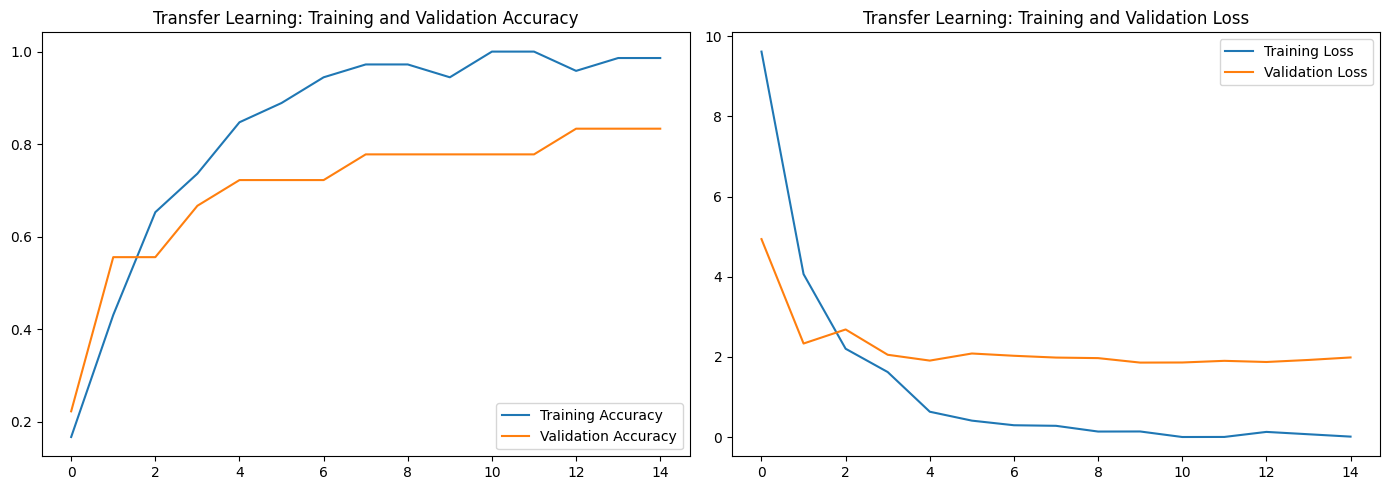

In [ ]:
acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']
loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range_tl = range(len(acc_tl))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_tl, acc_tl, label='Training Accuracy')
plt.plot(epochs_range_tl, val_acc_tl, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Transfer Learning: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_tl, loss_tl, label='Training Loss')
plt.plot(epochs_range_tl, val_loss_tl, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Transfer Learning: Training and Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds_tl)
print(f"Transfer Learning Test Loss: {test_loss_tl:.4f}")
print(f"Transfer Learning Test Accuracy: {test_acc_tl:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.9333 - loss: 0.2666
Transfer Learning Test Loss: 0.2666
Transfer Learning Test Accuracy: 0.9333


In [ ]:
y_true_tl = np.concatenate([labels.numpy() for _, labels in test_ds_tl])
y_pred_probs_tl = transfer_model.predict(test_ds_tl)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

print("Predicted class labels:", y_pred_tl[:10])
print("Actual class labels:   ", y_true_tl[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
Predicted class labels: [0 0 0 0 0 1 1 1 1 1]
Actual class labels:    [0 0 0 0 0 1 1 1 1 1]


In [ ]:
print("Classification Report for Transfer Learning Model:\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

Classification Report for Transfer Learning Model:

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       1.00      1.00      1.00         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.80      0.80      0.80         5

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



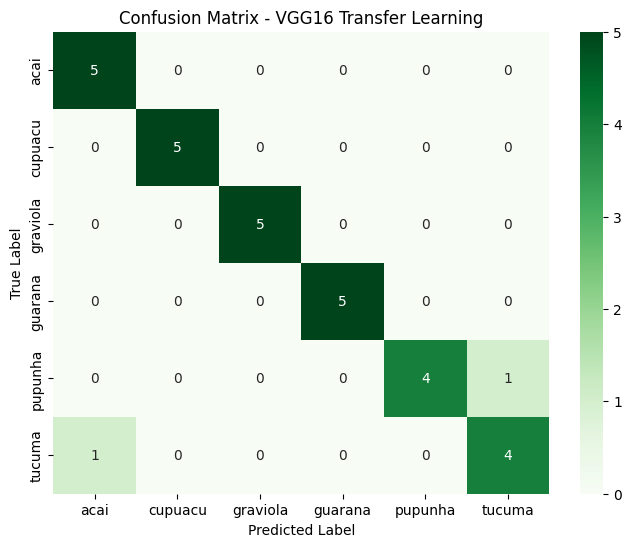

In [ ]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG16 Transfer Learning")
plt.show()

In [ ]:
transfer_model.save("vgg16_fruits_model.keras")
print("Transfer learning model saved successfully.")

Transfer learning model saved successfully.


In [ ]:
print("Model Comparison:")
print(f"CNN from Scratch Test Accuracy      : {test_acc:.4f}")
print(f"Transfer Learning Test Accuracy     : {test_acc_tl:.4f}")

if test_acc_tl > test_acc:
    print("Transfer learning improved the performance compared to training from scratch.")
elif test_acc_tl < test_acc:
    print("Training from scratch performed better than transfer learning in this case.")
else:
    print("Both models achieved similar performance.")

Model Comparison:
CNN from Scratch Test Accuracy      : 0.1333
Transfer Learning Test Accuracy     : 0.9333
Transfer learning improved the performance compared to training from scratch.
